0.0002300739288330078
0.003475666046142578
0.004014492034912109
0.003942012786865234
0.004009246826171875
0.003978729248046875
0.004012584686279297
0.003997087478637695
0.00400853157043457
0.003980875015258789
0.004035234451293945
0.003930568695068359
0.004025459289550781
0.004021406173706055
0.0039942264556884766
0.004006624221801758
0.0039882659912109375
0.00402379035949707
0.003986835479736328
0.0040225982666015625
0.0039882659912109375
0.0039751529693603516
0.004017829895019531
0.004016876220703125
0.003963470458984375
0.004119396209716797
0.00393366813659668
0.004075527191162109
0.003954648971557617
0.004023075103759766
0.0039196014404296875
0.0040895938873291016
0.0039517879486083984
0.00404810905456543
0.003964900970458984
0.0040340423583984375
0.004021167755126953
0.003980398178100586
0.004022121429443359
0.003988027572631836
0.004003763198852539
0.0039920806884765625
0.003983497619628906
0.004004955291748047
0.0040171146392822266
0.003985166549682617
0.004001617431640625
0.003

0.005078792572021484
0.0038759708404541016
0.0038814544677734375
0.003995656967163086
0.004004955291748047
0.0040667057037353516
0.003935575485229492
0.004004955291748047
0.004010438919067383
0.0039708614349365234
0.004014015197753906
0.003990888595581055
0.003992319107055664
0.004018068313598633
0.003943681716918945
0.0040132999420166016
0.0040073394775390625
0.004025459289550781
0.003949403762817383
0.004040241241455078
0.004067420959472656
0.003938198089599609
0.004071235656738281
0.004036426544189453
0.003908872604370117
0.003994941711425781
0.0039997100830078125
0.0040056705474853516
0.0039789676666259766
0.0039958953857421875
0.005098104476928711
0.004004955291748047
0.00397038459777832
0.004034757614135742
0.004027843475341797
0.003962993621826172
0.003983736038208008
0.004022836685180664
0.004014253616333008
0.00399017333984375
0.003958463668823242
0.0040454864501953125
0.004006147384643555
0.0039234161376953125
0.00403141975402832
0.003941059112548828
0.003996849060058594
0.00

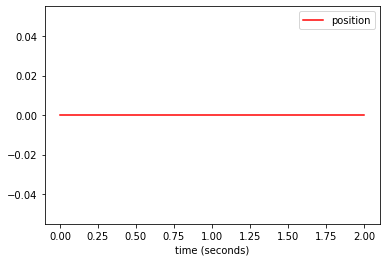

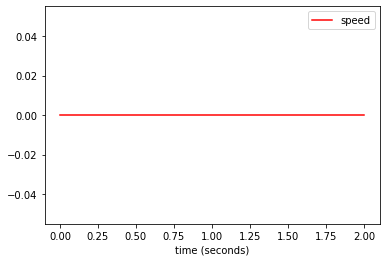

In [8]:
import sys
sys.path.append("../../")

import time
import math

from lib.data.dataplot import *
from lib.utils.time import *
from lib.system.basic import *
from lib.hardware.motor_driver import *

dpos = DataPlotter()
dpos.set_x("time (seconds)")
dpos.add_y("pos", "position")

dvel = DataPlotter()
dvel.set_x("time (seconds)")
dvel.add_y("speed", "speed")

m = MotorDriver()
m.open()

d = Derivator()

tm = Time()
tm.start()
while tm.get() < 2:

    delta_t = tm.elapsed()
    
    position = m.encoder()
    speed = d.evaluate(delta_t, position)
    
    position = position * 360/84000
    speed = speed * 360/84000
    
    m.pwm(200) # range [-4200, 4200]

    dpos.append_x(tm.get())
    dpos.append_y("pos", position)
    
    dvel.append_x(tm.get())
    dvel.append_y("speed", speed)
    
m.pwm(0)
dpos.plot()
dvel.plot()
